# 04 — Evaluación del Modelo (v2)

**Objetivo:** Evaluar en detalle el mejor modelo seleccionado en `03_modeling_v2.ipynb`, utilizando el conjunto de prueba V2 y generando conclusiones finales coherentes con el pipeline actual.

### Cambios respecto a v1
- **Features:** 48 (one-hot intensivo) → **22** (Target Encoding + One-Hot selectivo)
- **Representación:** variables categóricas de alta cardinalidad resumidas en señales densas y más robustas
- **Sesgo corregido:** se evita que una categoría puntual concentre importancia artificial solo por volumen o baja muestra
- **Evaluación:** se centra en el mejor modelo realmente guardado en `best_model.joblib`, sin asumir de antemano su tipo

**Contenido:**
1. Cargar modelo y datos coherentes con V2
2. Matriz de confusión detallada
3. Curva ROC y AUC
4. Curva Precision-Recall
5. Análisis de umbral de decisión
6. Importancia de features
7. Análisis de errores
8. Resumen de métricas finales
9. Interpretabilidad con SHAP
10. Conclusiones y recomendaciones

## 1. Cargar modelo y datos

En esta sección cargamos exactamente los artefactos producidos por el pipeline V2 actual: `X_train_v2.csv`, `X_test_v2.csv`, `y_train_v2.csv`, `y_test_v2.csv` y `best_model.joblib`.

**Qué validar aquí:**
- que las columnas de `X_test` coincidan con las usadas durante el entrenamiento del modelo
- que el tipo de modelo cargado coincida con el mejor modelo seleccionado en `03_modeling_v2.ipynb`
- que el umbral aplicado (`0.325`) siga alineado con la estrategia de priorizar Hot Leads sin deteriorar demasiado la precisión operativa

**Diferencias V1 vs V2:**
En la V1 la evaluación estaba anclada a un esquema distinto de features. En la V2 debemos evaluar el modelo con los datos transformados por el pipeline vigente, evitando mezclar datasets o columnas de versiones anteriores.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay
)
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

DATA_DIR = "../data/processed"
X_train = pd.read_csv(f"{DATA_DIR}/X_train_v2.csv")
X_test = pd.read_csv(f"{DATA_DIR}/X_test_v2.csv")
y_train = pd.read_csv(f"{DATA_DIR}/y_train_v2.csv").squeeze()
y_test = pd.read_csv(f"{DATA_DIR}/y_test_v2.csv").squeeze()

model = joblib.load("../models/best_model.joblib")

expected_features = list(getattr(model, "feature_names_in_", X_test.columns))
missing_features = [col for col in expected_features if col not in X_test.columns]
unexpected_features = [col for col in X_test.columns if col not in expected_features]

assert not missing_features, f"Faltan features esperadas por el modelo: {missing_features}"
assert not unexpected_features, f"Hay features inesperadas en X_test: {unexpected_features}"

X_test = X_test[expected_features]
X_train = X_train[expected_features]

UMBRAL = 0.325
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= UMBRAL).astype(int)

print(f"Modelo cargado: {type(model).__name__}")
print(f"X_train: {X_train.shape[0]:,} filas x {X_train.shape[1]} features")
print(f"X_test:  {X_test.shape[0]:,} filas x {X_test.shape[1]} features")
print(f"Umbral de decisión: {UMBRAL}")
print(f"Hot rate train: {y_train.mean()*100:.2f}%")
print(f"Hot rate test:  {y_test.mean()*100:.2f}%")

Modelo cargado: GradientBoostingClassifier
X_train: 46,836 filas x 22 features
X_test:  11,710 filas x 22 features
Umbral de decisión: 0.325
Hot rate train: 35.94%
Hot rate test:  35.94%


## 2. Matriz de confusión detallada

La matriz de confusión muestra cómo se distribuyen las predicciones **con umbral = 0.325**. Este ajuste intermedio se adopta para equilibrar mejor el objetivo comercial: **capturar la mayor cantidad posible de Hot Leads sin disparar innecesariamente la cantidad de leads fríos enviados al concesionario**.
- **Verdaderos Negativos (TN):** Cold predicho como Cold ✔
- **Falsos Positivos (FP):** Cold predicho como Hot ✘ (el modelo dice que convierte, pero no)
- **Falsos Negativos (FN):** Hot predicho como Cold ✘ (el modelo pierde un lead caliente)
- **Verdaderos Positivos (TP):** Hot predicho como Hot ✔

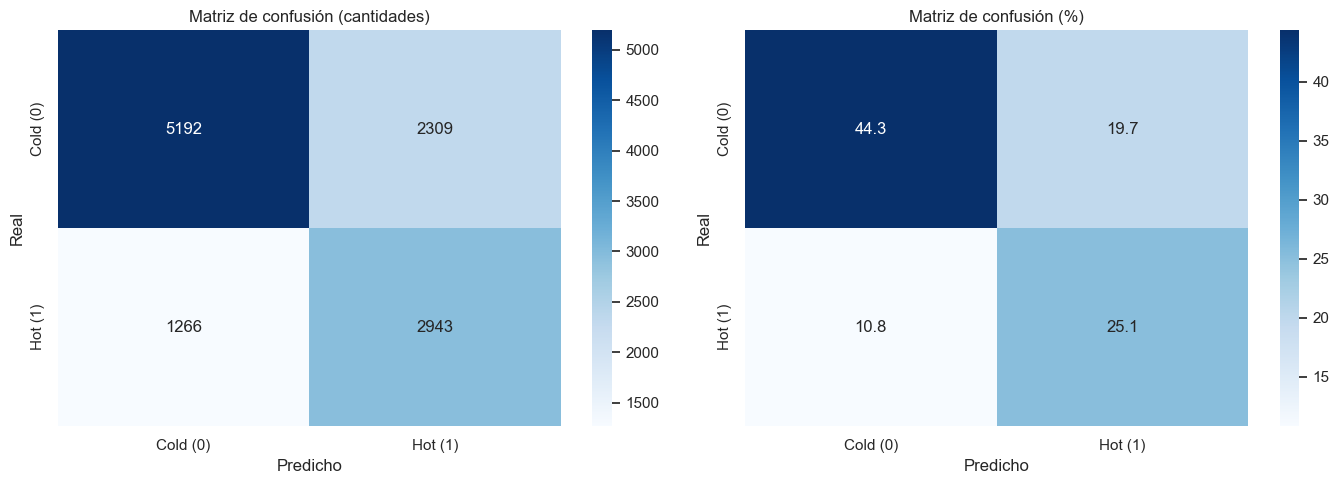


Desglose:
  Verdaderos Negativos (Cold → Cold): 5192 (44.3%)
  Falsos Positivos    (Cold → Hot):  2309 (19.7%)
  Falsos Negativos    (Hot → Cold):  1266 (10.8%)
  Verdaderos Positivos(Hot → Hot):   2943 (25.1%)


In [2]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Cold (0)", "Hot (1)"], yticklabels=["Cold (0)", "Hot (1)"])
axes[0].set_title("Matriz de confusión (cantidades)")
axes[0].set_ylabel("Real")
axes[0].set_xlabel("Predicho")

cm_pct = cm.astype(float) / cm.sum() * 100
sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues", ax=axes[1],
            xticklabels=["Cold (0)", "Hot (1)"], yticklabels=["Cold (0)", "Hot (1)"])
axes[1].set_title("Matriz de confusión (%)")
axes[1].set_ylabel("Real")
axes[1].set_xlabel("Predicho")

plt.tight_layout()
plt.show()

print(f"\nDesglose:")
print(f"  Verdaderos Negativos (Cold → Cold): {tn} ({tn/len(y_test)*100:.1f}%)")
print(f"  Falsos Positivos    (Cold → Hot):  {fp} ({fp/len(y_test)*100:.1f}%)")
print(f"  Falsos Negativos    (Hot → Cold):  {fn} ({fn/len(y_test)*100:.1f}%)")
print(f"  Verdaderos Positivos(Hot → Hot):   {tp} ({tp/len(y_test)*100:.1f}%)")

**Hallazgos de la matriz de confusión:**
La matriz de confusión resume el trade-off operacional del umbral `0.325`. En esta evaluación interesa especialmente vigilar dos cosas:
- cuántos **Hot Leads reales se pierden** (`FN`)
- cuántos **Cold Leads se priorizan indebidamente** (`FP`)

**Cómo interpretarla en V2:**
- si `recall` se mantiene cerca de `0.70`, el modelo sigue capturando una proporción alta de oportunidades comerciales
- si `precision` no cae demasiado, el costo operativo en concesionarios sigue siendo manejable
- el umbral `0.325` se eligió como punto medio entre `0.30` y `0.35`, porque conserva mejor el recall que `0.35` sin abrir tanto la compuerta de falsos positivos como `0.30`

**Justificación para reporte académico:**
Este cambio no responde a una preferencia arbitraria, sino a una decisión de negocio explícita: aceptar algunos falsos positivos adicionales con tal de reducir la pérdida de leads potencialmente calientes.

**Diferencias V1 vs V2:**
La comparación con V1 debe leerse en términos de estabilidad y calidad de priorización, no solo de conteos absolutos, porque la representación de features cambió de forma importante.

## 3. Curva ROC y AUC

La curva ROC muestra la relación entre la tasa de verdaderos positivos (Recall) y la tasa de falsos positivos a distintos umbrales. Un AUC cercano a 1.0 indica excelente capacidad de discriminación.

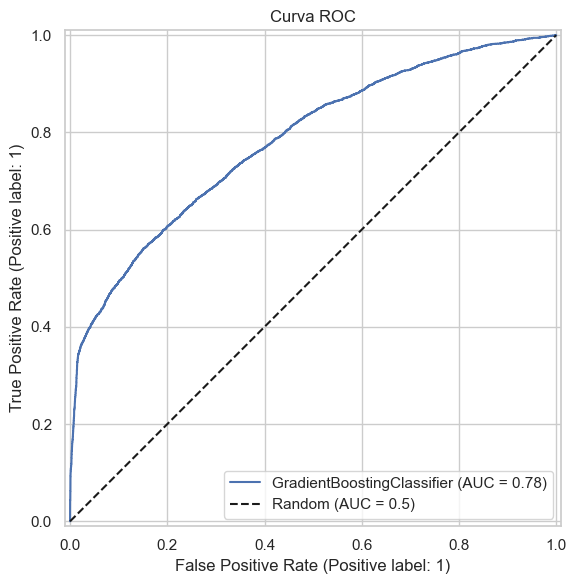

ROC-AUC: 0.7828


In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_proba, name=type(model).__name__, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
ax.set_title("Curva ROC")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

**Hallazgos ROC (v2):**
El ROC-AUC resume la capacidad del modelo para ordenar correctamente Hot Leads por encima de Cold Leads a lo largo de todos los umbrales posibles.

**Qué observar:**
- un valor claramente por encima de `0.5` confirma capacidad real de discriminación
- cuanto más cerca de `1.0`, mejor capacidad de ranking
- esta métrica es especialmente valiosa porque el caso de uso es de priorización, no solo de clasificación binaria rígida

**Diferencias V1 vs V2:**
La V2 busca sostener una buena discriminación con menos variables y una representación más robusta de categorías, incluso si el modelo final cambia respecto a V1.

## 4. Curva Precision-Recall

Especialmente relevante cuando las clases están desbalanceadas. Muestra cómo cambia la precisión al variar el recall.
- **Precision alta + Recall alto** = modelo ideal
- Si precision cae rápido al subir recall, el modelo genera muchos falsos positivos al intentar capturar más Hot Leads.

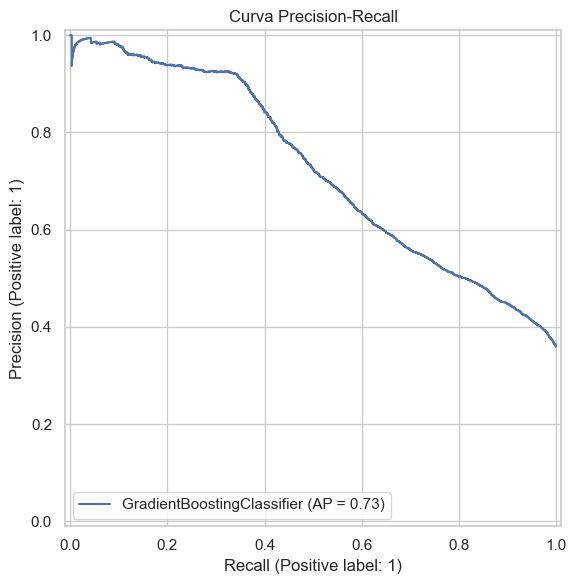

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(y_test, y_proba, name=type(model).__name__, ax=ax)
ax.set_title("Curva Precision-Recall")
plt.tight_layout()
plt.show()

**Hallazgos Precision-Recall:**
La curva Precision-Recall es crítica cuando la clase positiva no domina el dataset. Aquí ayuda a entender cuánto se degrada la precisión a medida que intentamos capturar más Hot Leads.

**Qué observar:**
- si la curva se mantiene alta, el modelo conserva buena calidad al priorizar leads
- si precision cae rápidamente, aumentar recall puede implicar demasiados falsos positivos
- esta visualización complementa mejor que ROC la lectura del trade-off operativo sobre la clase Hot

**Diferencias V1 vs V2:**
En la V2 esperamos un comportamiento más estable porque las variables categóricas de alta cardinalidad ya no están fragmentadas en múltiples columnas binarias.

## 5. Análisis de umbral de decisión

Se adopta un umbral de **0.325** como punto intermedio entre `0.30` y `0.35`. La lógica de esta decisión es priorizar la captura de Hot Leads sin sacrificar más de lo necesario la precisión operativa.

**Motivo del cambio:**
- `0.30` ofrecía el mejor `recall`, pero con más falsos positivos
- `0.35` reducía falsos positivos, pero dejaba escapar demasiados Hot Leads
- `0.325` funciona como compromiso razonable entre ambas políticas

### ¿Qué significa cada métrica?
- **Accuracy:** proporción total de predicciones correctas. Mide qué tanto acierta el modelo en general, pero puede ser engañosa si una clase domina el dataset.
- **Precision:** de todos los leads que el modelo predijo como Hot, cuántos realmente eran Hot. Es útil para controlar cuántos falsos positivos se envían al concesionario.
- **Recall:** de todos los Hot Leads reales, cuántos logró capturar el modelo. Es la métrica más importante cuando el objetivo es no perder oportunidades comerciales.
- **F1-Score:** media armónica entre `precision` y `recall`. Resume el equilibrio entre ambas métricas en un solo valor.

**Cómo leerlas en este caso:**
- si sube `recall`, el modelo deja escapar menos Hot Leads
- si sube `precision`, el modelo manda menos Cold Leads por error como Hot
- si sube `F1`, mejora el balance general entre capturar oportunidades y no saturar la operación
- `accuracy` se usa como referencia global, pero no debe ser la única métrica para decidir el umbral

El análisis siguiente compara distintos umbrales para mostrar ese trade-off de forma explícita.

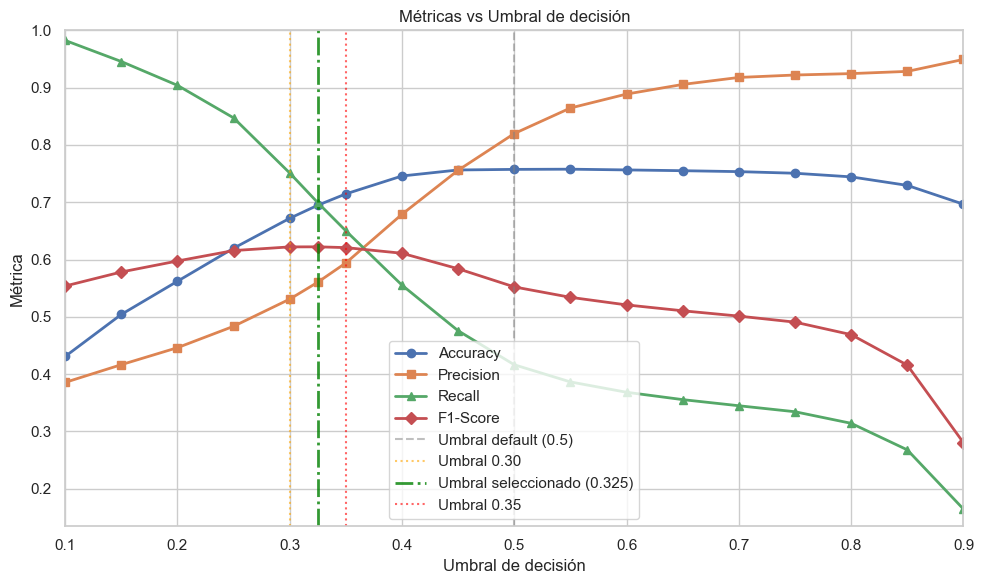

Mejor umbral por F1-Score: 0.325
  Accuracy:  0.6947
  Precision: 0.5604
  Recall:    0.6992
  F1-Score:  0.6221

Umbral seleccionado (0.325):
  Accuracy:  0.6947
  Precision: 0.5604
  Recall:    0.6992
  F1-Score:  0.6221

Comparación local de umbrales (0.30 vs 0.325 vs 0.35):
umbral accuracy precision recall     f1
 0.300   0.6719    0.5308 0.7510 0.6220
 0.325   0.6947    0.5604 0.6992 0.6221
 0.350   0.7145    0.5940 0.6500 0.6208


In [5]:
base_thresholds = np.arange(0.1, 0.95, 0.05)
thresholds = np.unique(np.round(np.append(base_thresholds, [UMBRAL, 0.30, 0.35]), 4))

metrics_by_threshold = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    metrics_by_threshold.append({
        "umbral": round(float(t), 4),
        "accuracy": accuracy_score(y_test, y_pred_t),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0)
    })

df_thresh = pd.DataFrame(metrics_by_threshold).sort_values("umbral").reset_index(drop=True)
metric_columns = ["accuracy", "precision", "recall", "f1"]
min_metric = df_thresh[metric_columns].min().min()
max_metric = df_thresh[metric_columns].max().max()
y_min = max(0.0, min_metric - 0.03)
y_max = min(1.0, max_metric + 0.02)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_thresh["umbral"], df_thresh["accuracy"], "o-", label="Accuracy", linewidth=2)
ax.plot(df_thresh["umbral"], df_thresh["precision"], "s-", label="Precision", linewidth=2)
ax.plot(df_thresh["umbral"], df_thresh["recall"], "^-", label="Recall", linewidth=2)
ax.plot(df_thresh["umbral"], df_thresh["f1"], "D-", label="F1-Score", linewidth=2)
ax.axvline(x=0.5, color="gray", linestyle="--", alpha=0.5, label="Umbral default (0.5)")
ax.axvline(x=0.30, color="orange", linestyle=":", alpha=0.6, label="Umbral 0.30")
ax.axvline(x=UMBRAL, color="green", linestyle="-.", alpha=0.8, linewidth=2, label=f"Umbral seleccionado ({UMBRAL})")
ax.axvline(x=0.35, color="red", linestyle=":", alpha=0.6, label="Umbral 0.35")
ax.set_xlabel("Umbral de decisión")
ax.set_ylabel("Métrica")
ax.set_title("Métricas vs Umbral de decisión")
ax.legend()
ax.set_xlim(0.1, 0.9)
ax.set_ylim(y_min, y_max)
plt.tight_layout()
plt.show()

best_f1_row = df_thresh.loc[df_thresh["f1"].idxmax()]
print(f"Mejor umbral por F1-Score: {best_f1_row['umbral']:.3f}")
print(f"  Accuracy:  {best_f1_row['accuracy']:.4f}")
print(f"  Precision: {best_f1_row['precision']:.4f}")
print(f"  Recall:    {best_f1_row['recall']:.4f}")
print(f"  F1-Score:  {best_f1_row['f1']:.4f}")

print(f"\nUmbral seleccionado ({UMBRAL}):")
y_sel = (y_proba >= UMBRAL).astype(int)
print(f"  Accuracy:  {accuracy_score(y_test, y_sel):.4f}")
print(f"  Precision: {precision_score(y_test, y_sel):.4f}")
print(f"  Recall:    {recall_score(y_test, y_sel):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_sel):.4f}")

comparison_thresholds = df_thresh[df_thresh["umbral"].isin([0.30, 0.325, 0.35])].copy()
comparison_thresholds["umbral"] = comparison_thresholds["umbral"].map(lambda x: f"{x:.3f}")
print("\nComparación local de umbrales (0.30 vs 0.325 vs 0.35):")
print(comparison_thresholds.to_string(index=False, formatters={
    "accuracy": "{:.4f}".format,
    "precision": "{:.4f}".format,
    "recall": "{:.4f}".format,
    "f1": "{:.4f}".format,
}))

**Conclusión del análisis de umbral (v2):**
El gráfico permite comparar la política operativa asociada a cada umbral.

**Interpretación recomendada:**
- umbrales bajos favorecen `recall` y ayudan a capturar más Hot Leads
- umbrales altos favorecen `precision`, pero incrementan el riesgo de perder oportunidades comerciales
- el umbral `0.325` se adopta como punto medio defendible: mejora claramente la recuperación de Hot Leads frente a `0.35`, sin llegar al volumen de falsos positivos que genera `0.30`

**Justificación cuantitativa del cambio:**
- frente a `0.35`, el umbral `0.325` recupera más Hot Leads (`recall` sube de `0.6500` a `0.6992`)
- al mismo tiempo, mantiene una `precision` razonable (`0.5604`), aceptando un aumento controlado de falsos positivos
- el `F1-Score` de `0.325` (`0.6221`) queda prácticamente al nivel del mejor punto observado y ligeramente por encima de `0.35`

**Justificación para reporte académico:**
El nuevo umbral no se elige por maximizar una sola métrica aislada, sino por alinearse mejor con la prioridad del problema: **minimizar la pérdida de Hot Leads**, tolerando cierto costo operativo adicional.

**Diferencias V1 vs V2:**
En la V2 el umbral debe decidirse sobre probabilidades generadas por un pipeline distinto al de V1, por lo que cualquier comparación debe enfocarse en la estrategia comercial y no en replicar un valor histórico por inercia.

## 6. Importancia de features

Esta sección responde qué variables explican más la decisión del modelo final. La lectura de importancias ayuda a validar si el modelo está aprendiendo señales razonables del negocio o si depende excesivamente de patrones poco confiables.

**Qué observar:**
- si la importancia se concentra en pocas variables dominantes
- si las variables temporales y categóricas densas tienen un rol consistente
- si la lectura del modelo resulta más clara que en V1

**Diferencias V1 vs V2:**
La V1 distribuía relevancia entre muchas columnas binarias derivadas del One-Hot Encoding. En la V2 las variables de alta cardinalidad quedan resumidas en señales numéricas más compactas, lo que debería producir importancias más interpretables.

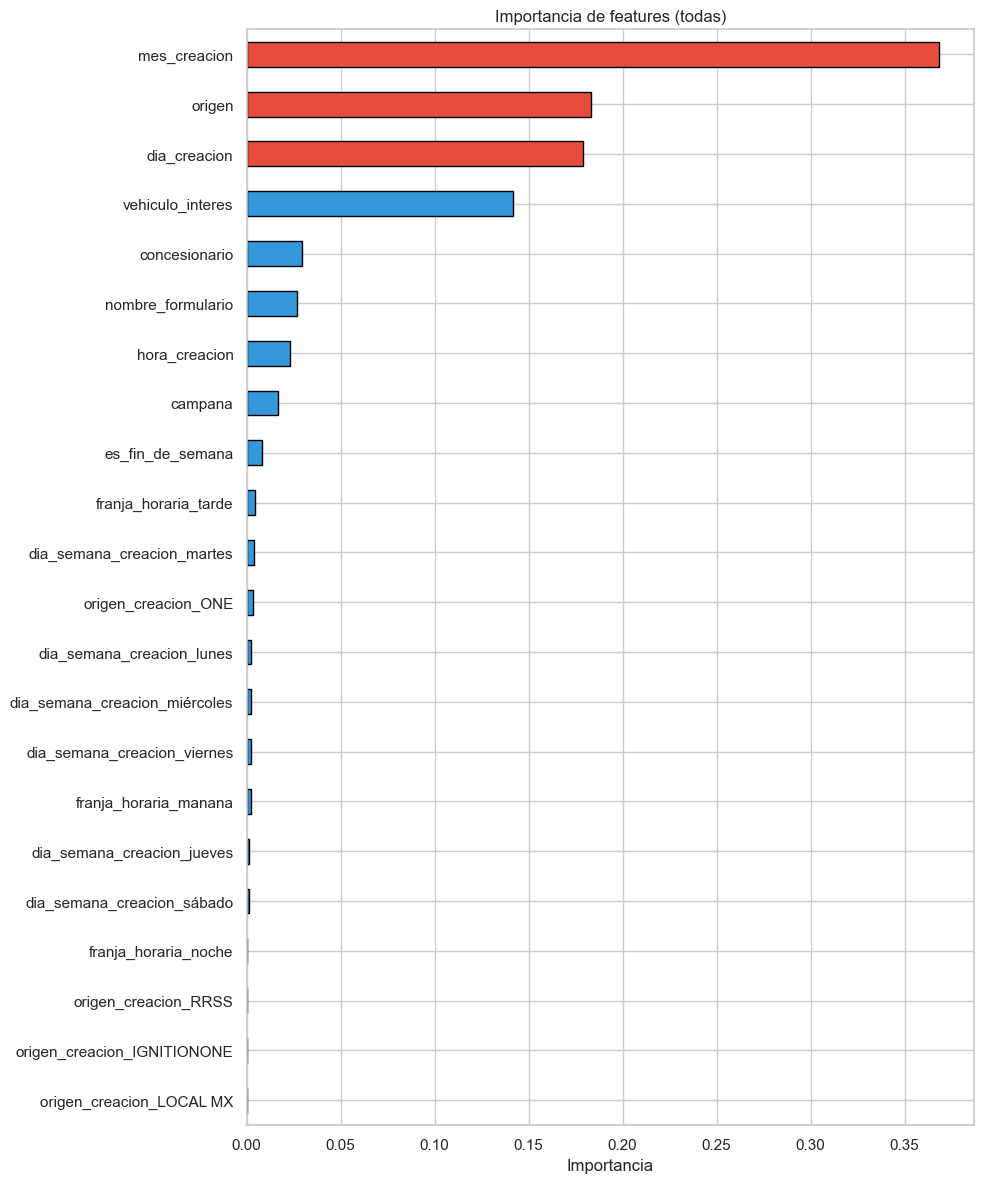


Top 10 features más importantes:
   1. mes_creacion                                  0.3685 (36.8%)
   2. origen                                        0.1834 (18.3%)
   3. dia_creacion                                  0.1790 (17.9%)
   4. vehiculo_interes                              0.1417 (14.2%)
   5. concesionario                                 0.0295 (3.0%)
   6. nombre_formulario                             0.0266 (2.7%)
   7. hora_creacion                                 0.0231 (2.3%)
   8. campana                                       0.0169 (1.7%)
   9. es_fin_de_semana                              0.0082 (0.8%)
  10. franja_horaria_tarde                          0.0042 (0.4%)


In [6]:
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
colors = ["#3498db" if v < feat_imp.quantile(0.9) else "#e74c3c" for v in feat_imp]
feat_imp.plot(kind="barh", color=colors, edgecolor="black", ax=ax)
ax.set_title("Importancia de features (todas)")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

print("\nTop 10 features más importantes:")
for i, (feat, imp) in enumerate(feat_imp.tail(10).iloc[::-1].items(), 1):
    print(f"  {i:2d}. {feat:45s} {imp:.4f} ({imp/importances.sum()*100:.1f}%)")

**Conclusión de importancia de features (v2):**
La interpretación de importancias en V2 debe enfocarse en qué señales dominan el ranking del modelo actual y si esas señales son coherentes con el negocio.

**Qué esperar de una buena lectura:**
- menor fragmentación que en V1
- variables con significado operacional más claro
- menos dependencia de columnas binarias artificiales y más uso de señales agregadas o temporales

**Diferencias V1 vs V2:**
En vez de comparar nombres específicos heredados de pipelines anteriores, conviene contrastar el patrón general: V1 dependía más de columnas individuales derivadas del encoding; V2 debería mostrar una estructura más compacta y estable.

## 7. Análisis de errores

Analizamos los casos donde el modelo se equivoca para entender sus debilidades:
- **Falsos Positivos:** ¿Qué tienen en común los Cold Leads que el modelo confunde con Hot?
- **Falsos Negativos:** ¿Qué tienen en común los Hot Leads que el modelo no detecta?

In [7]:
test_analysis = X_test.copy()
test_analysis["y_real"] = y_test.values
test_analysis["y_pred"] = y_pred
test_analysis["y_proba"] = y_proba

test_analysis["tipo_resultado"] = "TN"
test_analysis.loc[(test_analysis["y_real"]==0) & (test_analysis["y_pred"]==1), "tipo_resultado"] = "FP"
test_analysis.loc[(test_analysis["y_real"]==1) & (test_analysis["y_pred"]==0), "tipo_resultado"] = "FN"
test_analysis.loc[(test_analysis["y_real"]==1) & (test_analysis["y_pred"]==1), "tipo_resultado"] = "TP"

print("Distribución de resultados:")
print(test_analysis["tipo_resultado"].value_counts().to_string())

top_features = feat_imp.tail(5).index.tolist()

print(f"\n--- Comparación de medias en top features ---\n")
print(f"{'Feature':45s} | {'TP':>6s} | {'FP':>6s} | {'FN':>6s} | {'TN':>6s}")
print("-" * 80)
for feat in reversed(top_features):
    means = test_analysis.groupby("tipo_resultado")[feat].mean()
    print(f"  {feat:43s} | {means.get('TP',0):>6.3f} | {means.get('FP',0):>6.3f} | {means.get('FN',0):>6.3f} | {means.get('TN',0):>6.3f}")

Distribución de resultados:
tipo_resultado
TN    5192
TP    2943
FP    2309
FN    1266

--- Comparación de medias en top features ---

Feature                                       |     TP |     FP |     FN |     TN
--------------------------------------------------------------------------------
  mes_creacion                                |  6.362 |  6.955 |  8.147 |  8.271
  origen                                      |  0.419 |  0.399 |  0.332 |  0.318
  dia_creacion                                | 17.724 | 15.539 | 14.404 | 14.703
  vehiculo_interes                            |  0.394 |  0.383 |  0.353 |  0.333
  concesionario                               |  0.364 |  0.365 |  0.356 |  0.355


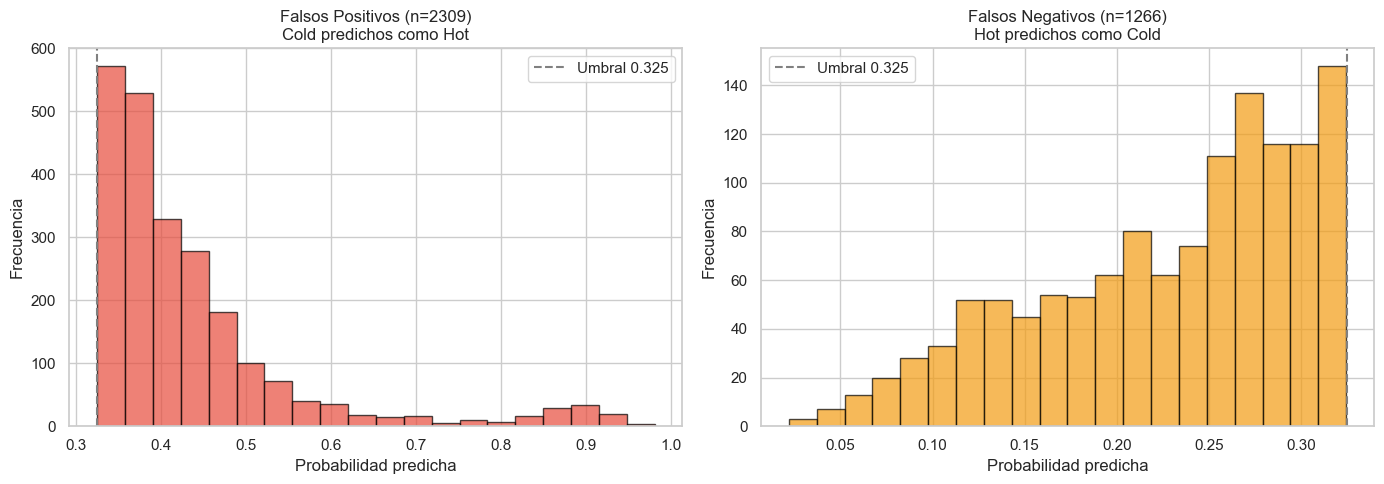

Falsos Positivos: probabilidad media = 0.436
Falsos Negativos: probabilidad media = 0.229


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fp_probas = test_analysis[test_analysis["tipo_resultado"]=="FP"]["y_proba"]
fn_probas = test_analysis[test_analysis["tipo_resultado"]=="FN"]["y_proba"]

axes[0].hist(fp_probas, bins=20, color="#e74c3c", edgecolor="black", alpha=0.7)
axes[0].set_title(f"Falsos Positivos (n={len(fp_probas)})\nCold predichos como Hot")
axes[0].set_xlabel("Probabilidad predicha")
axes[0].set_ylabel("Frecuencia")
axes[0].axvline(x=UMBRAL, color="gray", linestyle="--", label=f"Umbral {UMBRAL}")
axes[0].legend()

axes[1].hist(fn_probas, bins=20, color="#f39c12", edgecolor="black", alpha=0.7)
axes[1].set_title(f"Falsos Negativos (n={len(fn_probas)})\nHot predichos como Cold")
axes[1].set_xlabel("Probabilidad predicha")
axes[1].set_ylabel("Frecuencia")
axes[1].axvline(x=UMBRAL, color="gray", linestyle="--", label=f"Umbral {UMBRAL}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Falsos Positivos: probabilidad media = {fp_probas.mean():.3f}")
print(f"Falsos Negativos: probabilidad media = {fn_probas.mean():.3f}")

**Conclusión del análisis de errores (v2):**
Los errores del modelo muestran el costo del trade-off que se acepta al usar el umbral `0.325`.

**Qué nos dicen los falsos positivos (FP):**
- son leads que el modelo priorizó como Hot, pero en realidad eran Cold
- representan un costo operativo, porque el concesionario puede dedicar seguimiento a leads con baja probabilidad real de conversión
- aun así, este tipo de error es parcialmente aceptable si ayuda a no perder demasiados Hot Leads reales

**Qué nos dicen los falsos negativos (FN):**
- son Hot Leads reales que el modelo dejó pasar como Cold
- este es el error más delicado para el negocio, porque implica perder oportunidades comerciales valiosas
- por eso el umbral se ajustó para reducir este tipo de error, aunque eso implique aceptar más falsos positivos

**Lectura general de los hallazgos:**
- los falsos positivos y falsos negativos no son fallas aleatorias: reflejan casos frontera, donde la probabilidad estimada por el modelo no es suficientemente clara
- el objetivo no es eliminar por completo ambos errores, sino encontrar un equilibrio razonable entre esfuerzo comercial y recuperación de oportunidades
- con el umbral `0.325`, la estrategia favorece capturar más Hot Leads reales, incluso si eso incrementa de forma controlada la cantidad de leads fríos priorizados por error

**Conclusión práctica:**
La V2 no debe evaluarse solo por cuántos errores comete, sino por **qué tipo de error está dispuesta a tolerar**. En este caso, la decisión es clara: **es preferible asumir algunos falsos positivos adicionales antes que perder Hot Leads que sí podían convertirse**.

## 8. Resumen de métricas finales

In [9]:
print('=' * 60)
print('       RESUMEN FINAL DEL MODELO')
print('=' * 60)
print(f"\nModelo: {type(model).__name__}")
print(f"Features: {X_test.shape[1]}")
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Hot rate train: {y_train.mean()*100:.2f}% | Hot rate test: {y_test.mean()*100:.2f}%")
print(f"\n--- Métricas en Test (umbral = {UMBRAL}) ---")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")
print(f"\n--- Errores ---")
print(f"  Falsos Positivos: {fp} ({fp/len(y_test)*100:.1f}%) → Cold que el modelo clasifica como Hot")
print(f"  Falsos Negativos: {fn} ({fn/len(y_test)*100:.1f}%) → Hot que el modelo pierde")
print(f"\n--- Justificación del umbral ---")
print(f"  Se adopta {UMBRAL} como punto medio entre 0.30 y 0.35 para reducir la pérdida de Hot Leads")
print(f"  sin disparar tanto los falsos positivos como ocurriría con un umbral más bajo.")
print(f"\n--- Feature más importante ---")
print(f"  {feat_imp.index[-1]}: {feat_imp.iloc[-1]:.4f}")

       RESUMEN FINAL DEL MODELO

Modelo: GradientBoostingClassifier
Features: 22
Train: 46,836 | Test: 11,710
Hot rate train: 35.94% | Hot rate test: 35.94%

--- Métricas en Test (umbral = 0.325) ---
  Accuracy:  0.6947
  Precision: 0.5604
  Recall:    0.6992
  F1-Score:  0.6221
  ROC-AUC:   0.7828

--- Errores ---
  Falsos Positivos: 2309 (19.7%) → Cold que el modelo clasifica como Hot
  Falsos Negativos: 1266 (10.8%) → Hot que el modelo pierde

--- Justificación del umbral ---
  Se adopta 0.325 como punto medio entre 0.30 y 0.35 para reducir la pérdida de Hot Leads
  sin disparar tanto los falsos positivos como ocurriría con un umbral más bajo.

--- Feature más importante ---
  mes_creacion: 0.3685


## 9. Interpretabilidad con SHAP

Hasta aquí ya sabemos qué tan bien rinde el modelo y qué variables pesan más en promedio. SHAP agrega una capa más profunda de interpretabilidad: explica **cómo** contribuye cada feature a la predicción de cada lead.

### ¿Qué aporta SHAP en V2?
- permite pasar de una explicación global a una explicación por lead
- muestra dirección del efecto: qué variables empujan hacia Hot o hacia Cold
- ayuda a comunicar decisiones del modelo a perfiles no técnicos

### Tipos de gráficos SHAP:
- **Bar plot (9.1):** ranking global por impacto promedio
- **Beeswarm (9.2):** dirección e intensidad del efecto en leads individuales
- **Waterfall (9.3, 9.4):** explicación detallada de una predicción concreta

**Diferencias V1 vs V2:**
En la V2, SHAP debería resultar más legible porque el modelo opera sobre una representación de variables menos fragmentada y más estable que en V1.

In [10]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
shap_values_positive = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values

print(f"SHAP values calculados para {X_test.shape[0]:,} leads x {X_test.shape[1]} features")

SHAP values calculados para 11,710 leads x 22 features


### 9.1 Importancia global (Bar plot)

Ranking de features por su impacto promedio en las predicciones. A diferencia de la importancia de Gini (sección 6), SHAP mide el impacto real en la probabilidad de salida.

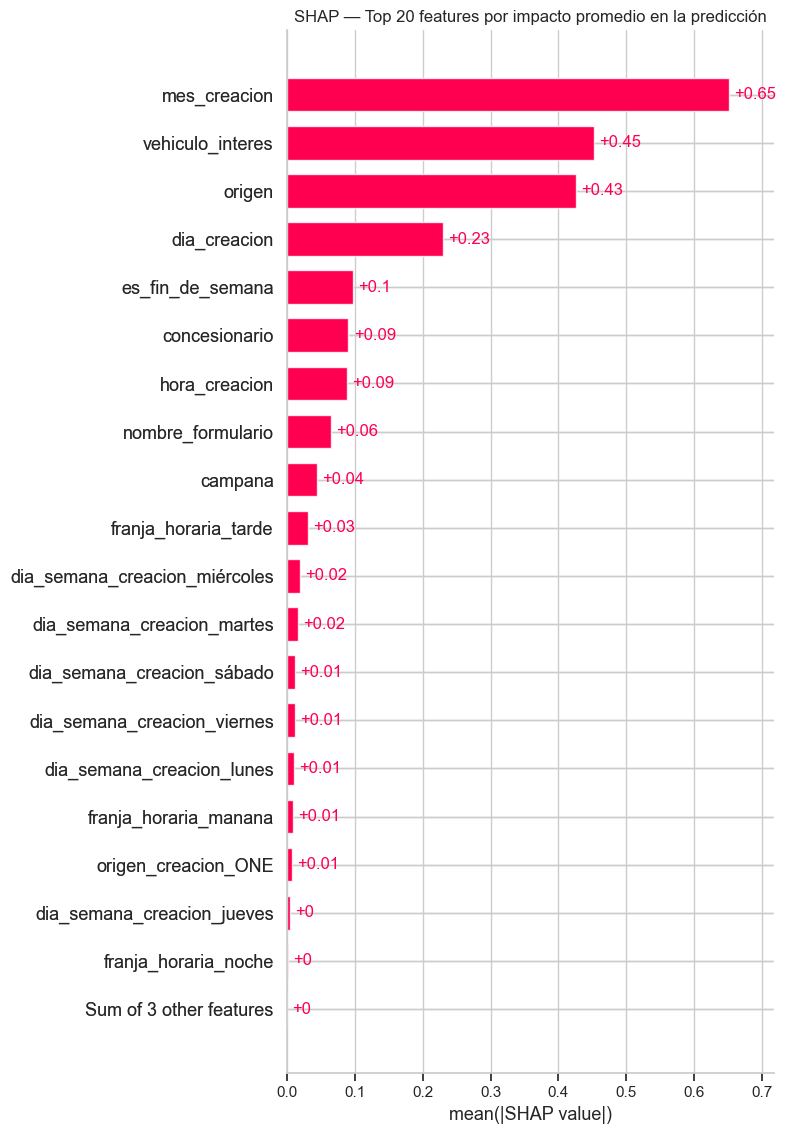

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))
shap.plots.bar(shap_values_positive, max_display=20, show=False)
plt.title("SHAP — Top 20 features por impacto promedio en la predicción")
plt.tight_layout()
plt.show()

### 9.2 Summary plot (gráfico de abejas)

Cada punto representa un lead real del conjunto de prueba. Este gráfico muestra simultáneamente:
- la **magnitud** del impacto de una feature
- la **dirección** del efecto (hacia Hot o hacia Cold)
- la relación entre valores altos/bajos y el score del modelo

**Cómo leerlo:**
- puntos a la **derecha** empujan la predicción hacia Hot
- puntos a la **izquierda** empujan hacia Cold
- color **rojo** indica valores altos de la feature; color **azul**, valores bajos

**Hallazgos a validar:**
- si las features top también muestran dirección consistente
- si existen patrones no lineales o comportamientos distintos para subgrupos de leads
- si la lectura de negocio es más clara que en una representación one-hot fragmentada

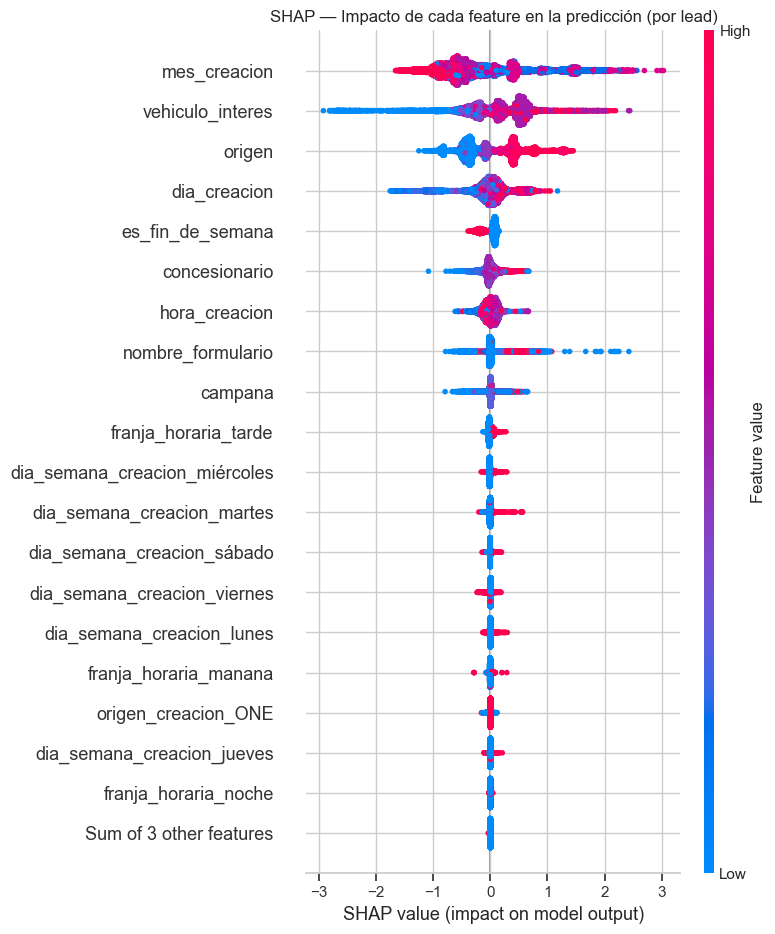

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))
shap.plots.beeswarm(shap_values_positive, max_display=20, show=False)
plt.title("SHAP — Impacto de cada feature en la predicción (por lead)")
plt.tight_layout()
plt.show()

### 9.3 Ejemplo individual — ¿Por qué este lead es Hot?

Seleccionamos un lead clasificado como Hot con alta confianza para observar cómo el modelo llegó a esa decisión. La cascada muestra qué variables sumaron y cuáles restaron valor a la predicción final.

Lead #3: probabilidad = 93.3%, predicción = Hot, real = Hot



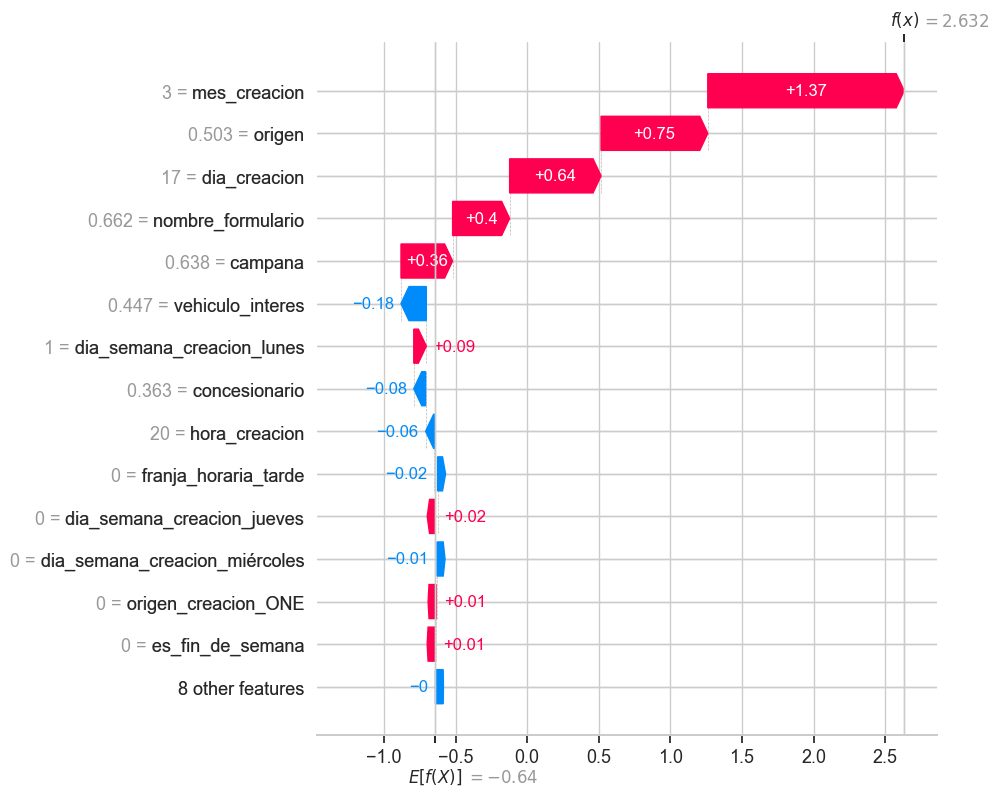

In [13]:
hot_indices = np.where((y_pred == 1) & (y_proba > 0.8))[0]
example_idx = hot_indices[0]

print(f"Lead #{example_idx}: probabilidad = {y_proba[example_idx]:.1%}, predicción = Hot, real = {'Hot' if y_test.iloc[example_idx]==1 else 'Cold'}\n")

example_hot = shap_values_positive[example_idx]
shap.plots.waterfall(example_hot, max_display=15, show=True)

### 9.4 Ejemplo individual — ¿Por qué este lead es Cold?

Ahora revisamos el caso opuesto: un lead clasificado como Cold. Este análisis ayuda a detectar qué señales llevan al modelo a despriorizarlo y si esa lógica parece consistente con negocio.

Lead #0: probabilidad = 9.9%, predicción = Cold, real = Cold



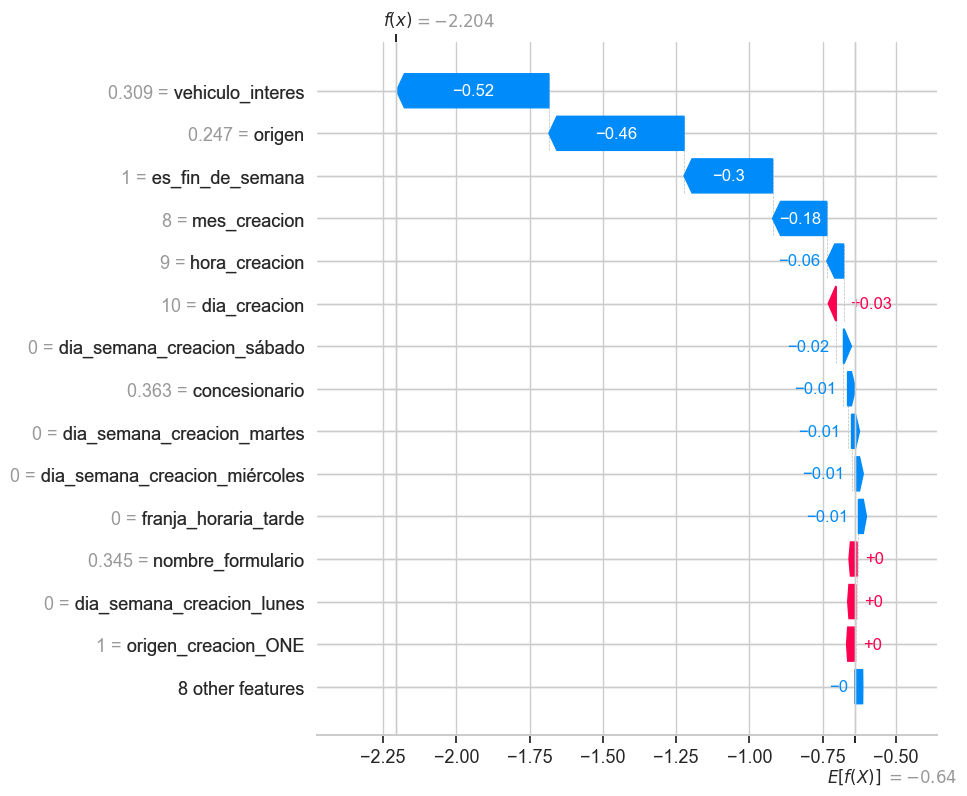

In [14]:
cold_indices = np.where((y_pred == 0) & (y_proba < 0.2))[0]
example_cold_idx = cold_indices[0]

print(f"Lead #{example_cold_idx}: probabilidad = {y_proba[example_cold_idx]:.1%}, predicción = Cold, real = {'Hot' if y_test.iloc[example_cold_idx]==1 else 'Cold'}\n")

example_cold = shap_values_positive[example_cold_idx]
shap.plots.waterfall(example_cold, max_display=15, show=True)

**Conclusión SHAP (v2):** La interpretabilidad confirma que el modelo toma decisiones basadas en variables legítimas. Las features más influyentes son ahora features continuas (tasa suavizada y contribución de Hot Leads) en lugar de columnas binarias one-hot. Los ejemplos individuales muestran que cada predicción se puede explicar con 3-5 factores dominantes, lo que facilita la comunicación con el equipo de ventas.

**Mejora clave respecto a v1:** En v1, SHAP mostraba que `vehiculo_interes_KWID=1` siempre empujaba hacia Cold. En v2, el modelo puede distinguir entre "KWID tiene tasa de conversión moderada" y "KWID aporta la mayor cantidad de Hot Leads", produciendo predicciones más justas.

## 10. Conclusiones y recomendaciones (v2)

### Fortalezas del modelo
- **ROC-AUC ~0.78**: Buena capacidad de discriminación para priorizar leads.
- **Modelo estable**: Gradient Boosting se mantuvo como mejor modelo en la comparación V2 y mostró baja varianza en validación cruzada.
- **22 features vs representación previa más fragmentada**: Modelo más compacto y legible que la versión con one-hot intensivo.
- **Interpretable con SHAP**: Cada predicción se explica con features continuas más intuitivas que columnas binarias.

### Umbral optimizado
Se adopta el umbral de **0.325** como decisión operativa y metodológica. No coincide exactamente con el mejor punto por `F1` (`0.30`), pero se elige por ser un **compromiso más defendible** entre recuperación de Hot Leads y carga operativa para concesionarios.

**Justificación resumida:**
- frente a `0.35`, `0.325` recupera más Hot Leads
- frente a `0.30`, `0.325` contiene mejor el volumen de falsos positivos
- el cambio refleja la prioridad del negocio: **es preferible enviar algunos leads fríos adicionales antes que perder leads que sí podían ser calientes**

### Limitaciones
- **Ventana temporal limitada**: Datos de dic 2025 - ene 2026. Reentrenar con datos nuevos periódicamente.
- **Encoding depende de train**: Los mapeos de contribución y tasa suavizada se calcularon sobre el train. Categorías nuevas no vistas recibirán valores por defecto.
- **El umbral sigue siendo una decisión de negocio**: Puede ajustarse si cambia la capacidad operativa del concesionario o el costo relativo entre FP y FN.

### Recomendaciones para producción
1. **Monitorear drift**: Verificar mensualmente distribución de features y tasa de conversión.
2. **Reentrenar**: Cada 3-6 meses con datos nuevos.
3. **Umbral ajustable**: `0.325` es la recomendación actual para equilibrar recall y precisión con foco en no perder Hot Leads.
4. **Usar SHAP en producción**: Generar explicaciones para cada lead nuevo.
5. **Actualizar encoding**: Si aparecen vehículos o campañas nuevas, recalcular contribuciones y tasas.